In [ ]:
# ===============================
# Core libraries
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ===============================
# Explainability libraries
# ===============================
!pip install shap
!pip install eli5
!pip install lime
import shap
import eli5
from eli5.sklearn import PermutationImportance
from lime.lime_tabular import LimeTabularExplainer

# ===============================
# Machine Learning utilities
# ===============================
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE

# ===============================
# Models
# ===============================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)

from xgboost import XGBClassifier

# ===============================
# Evaluation metrics
# ===============================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=01aec5c027440ea0cfba804c16c38eae48c240d25485b6d3b51da2e24406e578
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
# Load Wisconsin Breast Cancer Dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)   # 0 = malignant, 1 = benign

print("Dataset shape:", X.shape)
print("Class distribution:\n", y.value_counts())

Dataset shape: (569, 30)
Class distribution:
 1    357
0    212
Name: count, dtype: int64


#Clinically Motivated Feature Engineering

In [ ]:
# -------------------------------
# Ratio-based features
# -------------------------------
X['area_perimeter_ratio'] = X['mean area'] / X['mean perimeter']
X['radius_texture_ratio'] = X['mean radius'] / X['mean texture']
X['concavity_smoothness_ratio'] = X['mean concavity'] / X['mean smoothness']

# -------------------------------
# Delta (worst - mean) features
# -------------------------------
X['radius_delta'] = X['worst radius'] - X['mean radius']
X['area_delta'] = X['worst area'] - X['mean area']
X['concavity_delta'] = X['worst concavity'] - X['mean concavity']

# -------------------------------
# Aggregated severity indicators
# -------------------------------
mean_features = [c for c in X.columns if 'mean' in c]
worst_features = [c for c in X.columns if 'worst' in c]
se_features = [c for c in X.columns if 'error' in c]

X['mean_severity'] = X[mean_features].mean(axis=1)
X['worst_severity'] = X[worst_features].mean(axis=1)
X['error_severity'] = X[se_features].mean(axis=1)

print("Total features after engineering:", X.shape[1])

Total features after engineering: 39


#Train–Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Feature Selection (RFE + Random Forest)

In [ ]:
rf_for_rfe = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rfe = RFE(
    estimator=rf_for_rfe,
    n_features_to_select=15
)

rfe.fit(X_train_scaled, y_train)

selected_features = X_train.columns[rfe.support_]

X_train_sel = X_train_scaled[:, rfe.support_]
X_test_sel = X_test_scaled[:, rfe.support_]

print("Selected Features:")
for f in selected_features:
    print("-", f)

Selected Features:
- mean radius
- mean area
- mean concavity
- mean concave points
- worst radius
- worst texture
- worst perimeter
- worst area
- worst smoothness
- worst concavity
- worst concave points
- radius_delta
- area_delta
- mean_severity
- worst_severity


#Baseline Models

In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=500)
lr.fit(X_train_sel, y_train)

# Support Vector Machine
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train_sel, y_train)

SVC(probability=True)

#Hyperparameter Tuning: Random Forest

In [ ]:
rf_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

rf_grid.fit(X_train_sel, y_train)
best_rf = rf_grid.best_estimator_

print("Best RF Params:", rf_grid.best_params_)

Best RF Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


#Hyperparameter Tuning: Gradient Boosting

In [ ]:
gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
    'subsample': [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

gb_grid.fit(X_train_sel, y_train)
best_gb = gb_grid.best_estimator_

print("Best GB Params:", gb_grid.best_params_)

Best GB Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}


#Hyperparameter Tuning: XGBoost

In [ ]:
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42
    ),
    xgb_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

xgb_grid.fit(X_train_sel, y_train)
best_xgb = xgb_grid.best_estimator_

print("Best XGB Params:", xgb_grid.best_params_)

Best XGB Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


#Evaluation Function

In [ ]:
def evaluate_model(model, X, y, name):
    y_pred = model.predict(X)
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y, y_pred))
    print("Precision:", precision_score(y, y_pred))
    print("Recall   :", recall_score(y, y_pred))
    print("F1-score :", f1_score(y, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y, y_pred))

#Evaluate Individual Models

In [ ]:
evaluate_model(lr, X_test_sel, y_test, "Logistic Regression")
evaluate_model(svm, X_test_sel, y_test, "Support Vector Machine")
evaluate_model(best_rf, X_test_sel, y_test, "Random Forest (Tuned)")
evaluate_model(best_gb, X_test_sel, y_test, "Gradient Boosting (Tuned)")
evaluate_model(best_xgb, X_test_sel, y_test, "XGBoost (Tuned)")



Logistic Regression
Accuracy : 0.9736842105263158
Precision: 0.9859154929577465
Recall   : 0.9722222222222222
F1-score : 0.9790209790209791
Confusion Matrix:
 [[41  1]
 [ 2 70]]

Support Vector Machine
Accuracy : 0.9649122807017544
Precision: 0.9722222222222222
Recall   : 0.9722222222222222
F1-score : 0.9722222222222222
Confusion Matrix:
 [[40  2]
 [ 2 70]]

Random Forest (Tuned)
Accuracy : 0.9649122807017544
Precision: 0.9722222222222222
Recall   : 0.9722222222222222
F1-score : 0.9722222222222222
Confusion Matrix:
 [[40  2]
 [ 2 70]]

Gradient Boosting (Tuned)
Accuracy : 0.956140350877193
Precision: 0.958904109589041
Recall   : 0.9722222222222222
F1-score : 0.9655172413793104
Confusion Matrix:
 [[39  3]
 [ 2 70]]

XGBoost (Tuned)
Accuracy : 0.956140350877193
Precision: 0.971830985915493
Recall   : 0.9583333333333334
F1-score : 0.965034965034965
Confusion Matrix:
 [[40  2]
 [ 3 69]]


#Final Hybrid Ensemble

In [ ]:
final_ensemble = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('svm', svm),
        ('rf', best_rf),
        ('gb', best_gb),
        ('xgb', best_xgb)
    ],
    voting='soft'
)

final_ensemble.fit(X_train_sel, y_train)

evaluate_model(
    final_ensemble,
    X_test_sel,
    y_test,
    "Final Hybrid Ensemble"
)


Final Hybrid Ensemble
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1-score : 0.9861111111111112
Confusion Matrix:
 [[41  1]
 [ 1 71]]


#SHAP Explainability (Tree-Based)

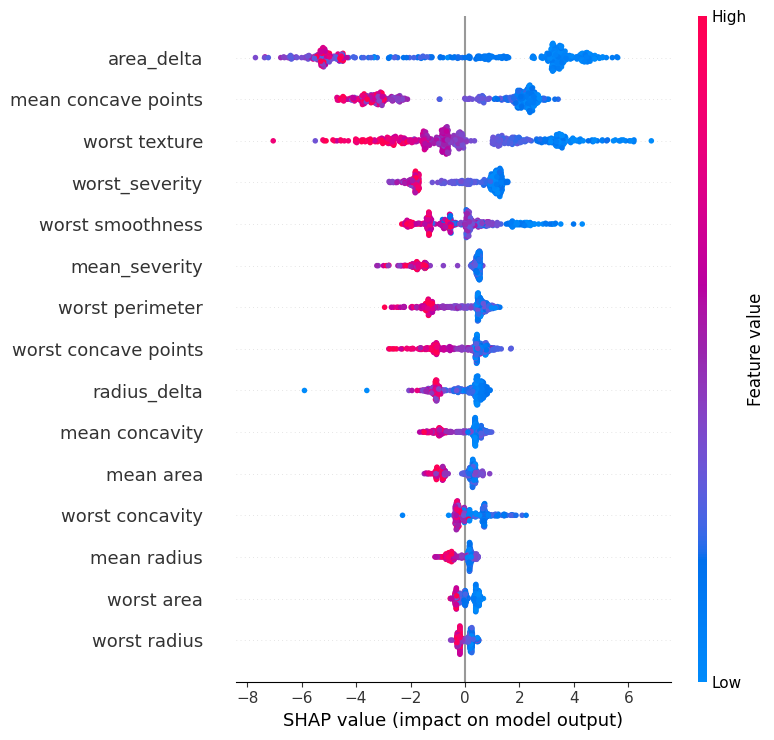

In [ ]:
explainer = shap.TreeExplainer(best_gb)
shap_values = explainer.shap_values(X_train_sel)

# Global explanation
shap.summary_plot(
    shap_values,
    X_train_sel,
    feature_names=selected_features
)

#LIME Explainability (Ensemble)

In [ ]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train_sel,
    feature_names=selected_features,
    class_names=['Malignant', 'Benign'],
    mode='classification'
)

i = 0
lime_exp = lime_explainer.explain_instance(
    X_test_sel[i],
    final_ensemble.predict_proba,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)

#ELI5 Permutation Importance (GLOBAL, MODEL-AGNOSTIC)

In [ ]:
# Permutation importance on Gradient Boosting (best clinical model)
perm = PermutationImportance(
    best_gb,
    scoring='recall',
    n_iter=10,
    random_state=42
)

perm.fit(X_test_sel, y_test)

eli5.show_weights(
    perm,
    feature_names=selected_features.tolist()
)

Weight,Feature
0.0403 ± 0.0361,worst texture
0.0389 ± 0.0444,area_delta
0.0375 ± 0.0413,mean concave points
0.0125 ± 0.0150,mean concavity
0.0028 ± 0.0299,mean_severity
0.0028 ± 0.0208,worst_severity
0.0014 ± 0.0083,worst concavity
-0.0000 ± 0.0215,worst concave points
-0.0042 ± 0.0127,worst perimeter
-0.0042 ± 0.0178,worst smoothness


#Model Performance Comparison (Bar Chart)

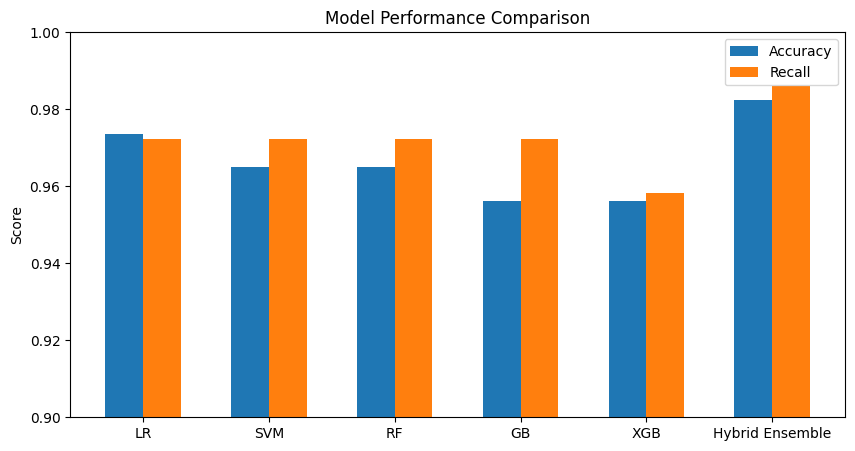

In [ ]:
# Model performance summary
models = [
    "LR", "SVM", "RF", "GB", "XGB", "Hybrid Ensemble"
]

accuracy = [0.9737, 0.9649, 0.9649, 0.9561, 0.9561, 0.9825]
recall =   [0.9722, 0.9722, 0.9722, 0.9722, 0.9583, 0.9861]

x = np.arange(len(models))

plt.figure(figsize=(10, 5))
plt.bar(x - 0.15, accuracy, width=0.3, label="Accuracy")
plt.bar(x + 0.15, recall, width=0.3, label="Recall")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.ylim(0.9, 1.0)
plt.show()

#Confusion Matrix (Final Hybrid Ensemble)

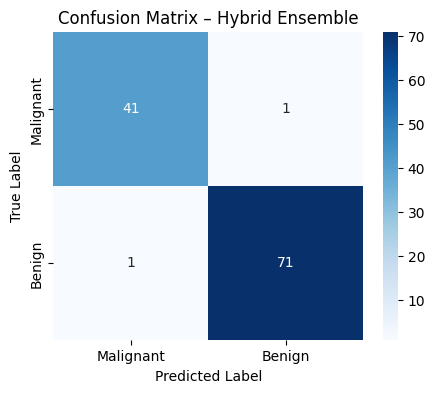

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, final_ensemble.predict(X_test_sel))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Malignant", "Benign"],
            yticklabels=["Malignant", "Benign"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Hybrid Ensemble")
plt.show()

#ROC Curve (Final Model)

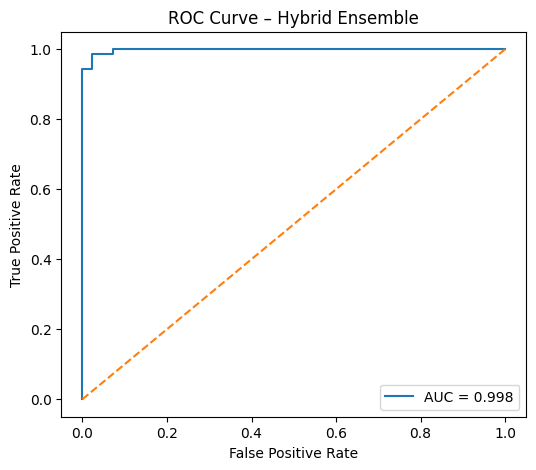

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = final_ensemble.predict_proba(X_test_sel)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Hybrid Ensemble")
plt.legend()
plt.show()

#Precision–Recall Curve

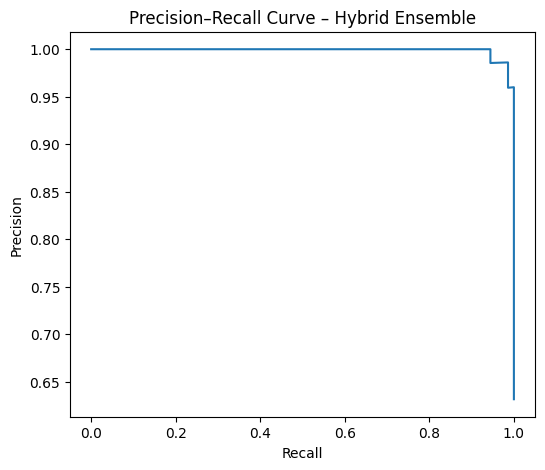

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Hybrid Ensemble")
plt.show()

#ELI5 Permutation Importance (Bar Plot)

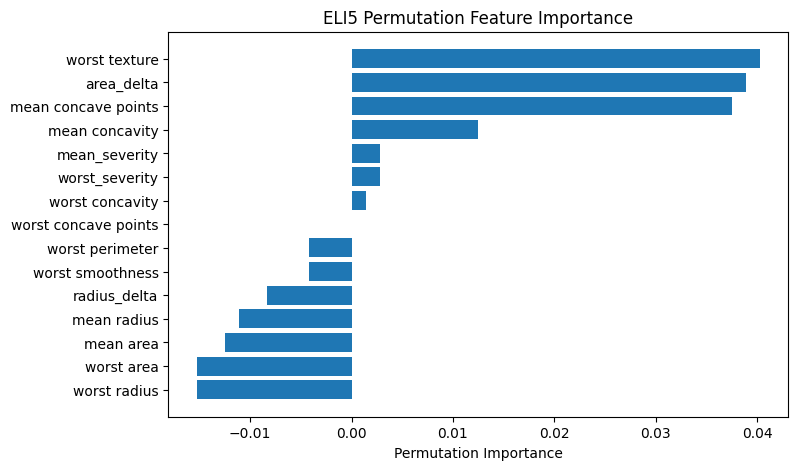

In [ ]:
weights = perm.feature_importances_
features = selected_features

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": weights
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Permutation Importance")
plt.title("ELI5 Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.show()

#Prediction Probability Scatter Plot

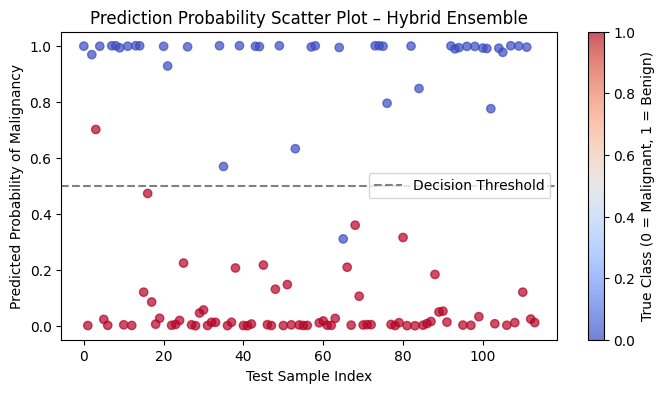

In [ ]:
# Get predicted probabilities for malignant class (class 1 = benign, so use malignant = 1 - prob)
y_prob = final_ensemble.predict_proba(X_test_sel)

# Probability of malignant class
malignant_prob = 1 - y_prob[:, 1]

# Create scatter plot
plt.figure(figsize=(8, 4))

plt.scatter(
    range(len(malignant_prob)),
    malignant_prob,
    c=y_test,
    cmap='coolwarm',
    alpha=0.7
)

plt.axhline(0.5, linestyle='--', color='gray', label='Decision Threshold')

plt.xlabel("Test Sample Index")
plt.ylabel("Predicted Probability of Malignancy")
plt.title("Prediction Probability Scatter Plot – Hybrid Ensemble")
plt.colorbar(label="True Class (0 = Malignant, 1 = Benign)")
plt.legend()
plt.show()

#SORTED CONFIDENCE SCATTER

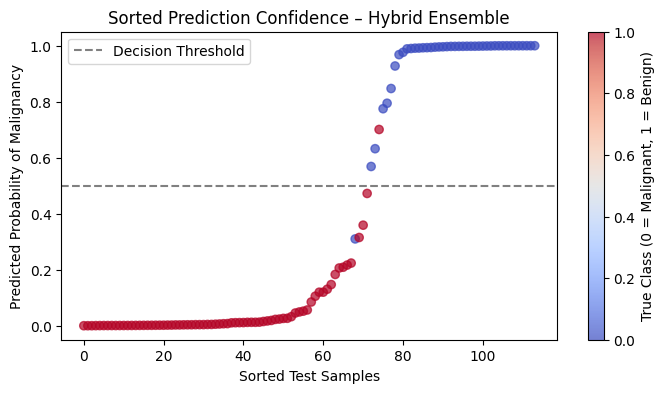

In [ ]:
# Sort by probability
sorted_idx = np.argsort(malignant_prob)

plt.figure(figsize=(8, 4))
plt.scatter(
    range(len(sorted_idx)),
    malignant_prob[sorted_idx],
    c=y_test.iloc[sorted_idx],
    cmap='coolwarm',
    alpha=0.7
)

plt.axhline(0.5, linestyle='--', color='gray', label='Decision Threshold')

plt.xlabel("Sorted Test Samples")
plt.ylabel("Predicted Probability of Malignancy")
plt.title("Sorted Prediction Confidence – Hybrid Ensemble")
plt.colorbar(label="True Class (0 = Malignant, 1 = Benign)")
plt.legend()
plt.show()

#Cross-Validation Performance (Mean ± Std)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate Hybrid Ensemble using Recall (clinical metric)
cv_recall = cross_val_score(
    final_ensemble,
    X_train_sel,
    y_train,
    cv=cv,
    scoring='recall'
)

print("Cross-Validation Recall Scores:", cv_recall)
print("Mean Recall:", cv_recall.mean())
print("Std Recall :", cv_recall.std())

Cross-Validation Recall Scores: [1.         0.98245614 0.96491228 1.         1.        ]
Mean Recall: 0.9894736842105264
Std Recall : 0.014035087719298251


#Paired Statistical Significance Test (McNemar or Paired t-test)

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

# Predictions
y_pred_lr = lr.predict(X_test_sel)
y_pred_ensemble = final_ensemble.predict(X_test_sel)

# Build contingency table
both_correct = np.sum((y_pred_lr == y_test) & (y_pred_ensemble == y_test))
lr_correct_ens_wrong = np.sum((y_pred_lr == y_test) & (y_pred_ensemble != y_test))
lr_wrong_ens_correct = np.sum((y_pred_lr != y_test) & (y_pred_ensemble == y_test))
both_wrong = np.sum((y_pred_lr != y_test) & (y_pred_ensemble != y_test))

table = [[both_correct, lr_correct_ens_wrong],
         [lr_wrong_ens_correct, both_wrong]]

result = mcnemar(table, exact=True)

print("McNemar statistic:", result.statistic)
print("p-value:", result.pvalue)

McNemar statistic: 1.0
p-value: 1.0


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score

In [ ]:
rf_param_grid = {
    'ensemble__rf__n_estimators': [200, 300],
    'ensemble__rf__max_depth': [None, 10]
}

gb_param_grid = {
    'ensemble__gb__n_estimators': [100, 200],
    'ensemble__gb__learning_rate': [0.05, 0.1]
}

xgb_param_grid = {
    'ensemble__xgb__n_estimators': [100, 200],
    'ensemble__xgb__max_depth': [3, 4]
}

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rfe', RFE(
        estimator=RandomForestClassifier(n_estimators=200, random_state=42),
        n_features_to_select=15
    )),
    ('ensemble', VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=500)),
            ('svm', SVC(kernel='rbf', probability=True)),
            ('rf', RandomForestClassifier(random_state=42)),
            ('gb', GradientBoostingClassifier(random_state=42)),
            ('xgb', XGBClassifier(
                objective='binary:logistic',
                eval_metric='logloss',
                use_label_encoder=False,
                random_state=42
            ))
        ],
        voting='soft'
    ))
])

In [ ]:
param_grid = {
    **rf_param_grid,
    **gb_param_grid,
    **xgb_param_grid
}

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring='recall',
    n_jobs=-1
)

In [ ]:
outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

outer_recalls = []

for train_idx, test_idx in outer_cv.split(X, y):
    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    # Fit inner CV on training fold
    grid_search.fit(X_train_cv, y_train_cv)

    # Evaluate on unseen outer fold
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_cv)

    recall = recall_score(y_test_cv, y_pred)
    outer_recalls.append(recall)

    print("Outer fold recall:", recall)

Outer fold recall: 0.9831932773109243
Outer fold recall: 0.9747899159663865
Outer fold recall: 0.9831932773109243


In [ ]:
outer_recalls = np.array(outer_recalls)

print("Nested CV Recall Scores:", outer_recalls)
print("Mean Recall:", outer_recalls.mean())
print("Std Recall :", outer_recalls.std())

Nested CV Recall Scores: [0.98319328 0.97478992 0.98319328]
Mean Recall: 0.9803921568627451
Std Recall : 0.0039613825276557145
